# 12 - Beat by beat, lead by lead: marking the abnormal wave

[Notebook 11](11-jr-section-maps.ipynb) painted 0.25 s bands across all 12 leads. It found single odd beats,
but it could not say *which lead*, and it painted benign slow or irregular rhythms red too often.
[Experiment 042](../docs/experiment-042-lead-wave-maps-results.md) tried two per-lead alternatives. This
notebook shows the one that improved on notebook 11 by the experiment's prespecified rule: the
**beat-aligned wave map**.

The idea:

1. Find every heartbeat (its R peak).
2. Cut each beat, in each of the 12 leads, into four waves at fixed times around the R peak:
   **P** (-0.25 to -0.06 s), **QRS** (-0.06 to +0.08 s), **ST** (+0.08 to +0.20 s) and **T** (+0.20 to
   +0.45 s).
3. For each lead and wave (48 combinations), learn what the wave looks like in the 63,479 beats of 5,872
   healthy training ECGs.
4. A wave far from its healthy shape gets a high score. Above a threshold, that wave of that lead is painted
   red.

There is no neural network here: the comparison is on the raw signal. The threshold is the one the
experiment fixed: only 5% of normal development ECGs get any red.

In [1]:
import os
import sys
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = ""

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import json
from concurrent.futures import ThreadPoolExecutor
from io import BytesIO

import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.figure import Figure
from PIL import Image as PILImage

from ecg_experiment.eda.ptbxl import load_metadata, load_statements
from ecg_experiment.external_encoders import read_ptb_float64
from ecg_experiment.fragment_localization import premature_windows, r_peaks
from ecg_experiment.full_development import cohorts, ptb_table
from ecg_experiment.lead_wave_maps import (
    WAVES,
    beat_pieces,
    beat_unit_map,
    fit_wave_references,
    plot_lead_marks,
    red_marks,
    wave_scores,
)
from ecg_experiment.waveforms import LEADS

RUN = ROOT / "outputs/experiment042_lead_wave_maps_v1"
RUN041 = ROOT / "outputs/experiment041_fragment_localization_v1"
result = json.loads((RUN / "result.json").read_text())
result041 = json.loads((RUN041 / "result.json").read_text())
saved = np.load(RUN / "unit_scores.npz")
saved041 = np.load(RUN041 / "section_scores.npz")
threshold = result["thresholds"]["U_B"]
groups = cohorts(ptb_table())
table = ptb_table().set_index("ecg_id")
print(f"U_B red threshold: {threshold:.1f}")


def display_small(figure: Figure, dpi: int = 65) -> None:
    """Show a figure at low resolution to keep the notebook small."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi)
    small = BytesIO()
    PILImage.open(buffer).convert("RGB").quantize(colors=16).save(small, format="png", optimize=True)
    display(Image(small.getvalue()))

U_B red threshold: 1158.8


## 1. Learning what healthy waves look like

The experiment did not save its fitted references, so this cell rebuilds them exactly as the experiment did:
it reads the 5,872 healthy training ECGs, cuts their beats and fits one reference per lead and wave. It takes
about a minute.

In [3]:
train = groups["train"]
caches = ("outputs/experiment016_xecg_probe_finetune/features",
          "data/processed/pretrained/ecg-jepa-full-public",
          "outputs/experiment004_cpc_40k/released_features")
common = set.intersection(*(set(np.load(ROOT / folder / "ecg_ids.npy").astype(np.int64).tolist())
                            for folder in caches))
fit = train[(train["standard"] == 0) & train["ecg_id"].isin(common)]
with ThreadPoolExecutor(4) as pool:
    fit_beats = list(pool.map(lambda stem: beat_pieces(read_ptb_float64(stem)), fit["filename_hr"]))
healthy = {name: np.concatenate([pieces[name] for _, pieces in fit_beats]) for name in WAVES}
references = fit_wave_references(healthy)
count = sum(len(r) for r in references.values())
print(f"{len(fit)} healthy ECGs, {len(healthy['QRS'])} beats, {count} references")

5872 healthy ECGs, 63479 beats, 48 references


## 2. One ECG, cut into beats and waves

PTB-XL ECG 219 has a premature ventricular beat. First, how the beats of lead II are cut: each colour is one
wave window around an R peak.

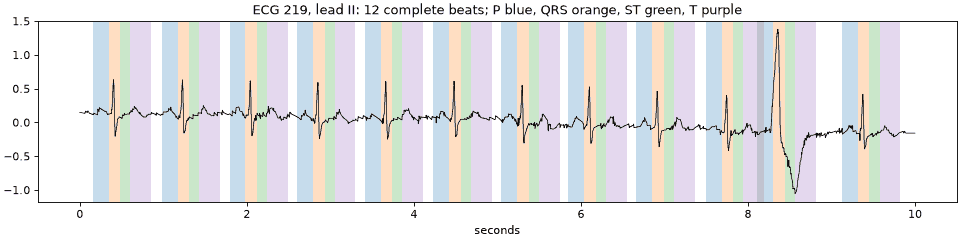

In [4]:
ECG = 219
signal = read_ptb_float64(table.at[ECG, "filename_hr"])
r_times, pieces = beat_pieces(signal)
colours = {"P": "tab:blue", "QRS": "tab:orange", "ST": "tab:green", "T": "tab:purple"}
figure = Figure(figsize=(12, 3), layout="constrained")
axis = figure.subplots()
axis.plot(np.arange(signal.shape[1]) / 500, signal[1], color="black", linewidth=0.7)
for r_time in r_times:
    for name, (low, high) in WAVES.items():
        axis.axvspan(r_time + low, r_time + high, color=colours[name], alpha=0.25, linewidth=0)
axis.set_title(f"ECG {ECG}, lead II: {len(r_times)} complete beats; P blue, QRS orange, ST green, T purple")
axis.set_xlabel("seconds")
display_small(figure, dpi=80)

Now the comparison. The grey lines are the lead II QRS of 300 healthy beats. The blue lines are the QRS of this ECG's beats, and a beat
whose score is above the red threshold is drawn in red. The legend gives each beat's score.

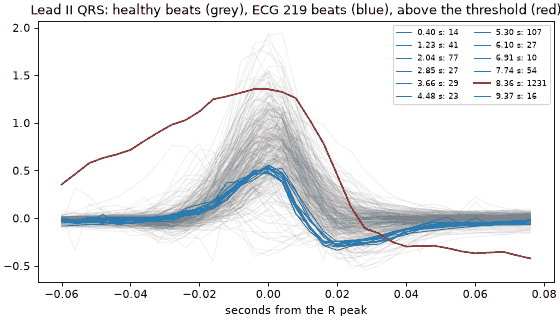

In [5]:
rng = np.random.default_rng(0)
figure = Figure(figsize=(7, 4), layout="constrained")
axis = figure.subplots()
times = np.arange(healthy["QRS"].shape[2]) * 2 / 500 + WAVES["QRS"][0]
for row in rng.choice(len(healthy["QRS"]), 300, replace=False):
    axis.plot(times, healthy["QRS"][row, 1], color="grey", alpha=0.15, linewidth=0.7)
scores = wave_scores(references, pieces)
for beat in range(len(r_times)):
    score = scores[beat, 1, 1]
    colour = "red" if score > threshold else "tab:blue"
    axis.plot(times, pieces["QRS"][beat, 1], color=colour, linewidth=1.5 if colour == "red" else 0.8,
              label=f"{r_times[beat]:.2f} s: {score:.0f}")
axis.set_title("Lead II QRS: healthy beats (grey), ECG 219 beats (blue), above the threshold (red)")
axis.set_xlabel("seconds from the R peak")
axis.legend(fontsize=7, ncol=2)
display_small(figure, dpi=80)

Each beat's score is its distance from the healthy QRS shapes of lead II (the number in the legend). The next
cell scores all 48 lead-and-wave pieces of every beat, checks them against the experiment's saved scores, and
paints red every piece above the threshold.

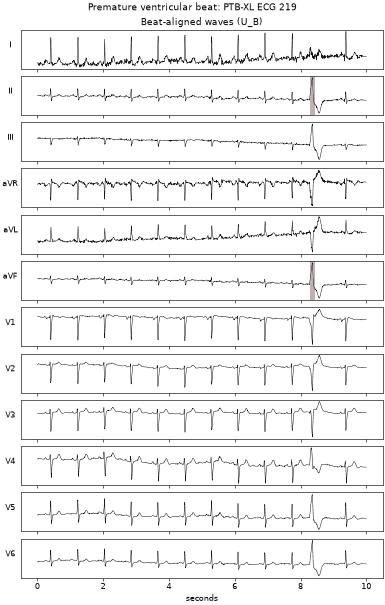

ECG 219 | red waves (lead, wave, beat R time): ['II QRS at 8.36 s', 'aVF QRS at 8.36 s']
           | 041 red bands start at (s): [np.float64(8.25), np.float64(8.5), np.float64(8.75)] | early beats by the rule at (s): [8.36] | max difference from saved scores: 0.0e+00


In [6]:
ids = saved["ecg_ids"]
offsets = saved["U_B_offsets"]


def saved_units(ecg_id: int) -> np.ndarray:
    """Return the experiment's saved U_B scores of one ECG."""
    row = int(np.flatnonzero(ids == ecg_id)[0])
    return saved["U_B_scores"][offsets[row]:offsets[row + 1]]


def show(ecg_id: int, title: str) -> None:
    """Plot one ECG with its red waves and print them, with 041's red time bands for comparison."""
    signal = read_ptb_float64(table.at[ecg_id, "filename_hr"])
    r_times, pieces = beat_pieces(signal)
    unit_map = beat_unit_map(wave_scores(references, pieces), r_times)
    difference = np.abs(unit_map.scores - saved_units(ecg_id)).max()
    marks = red_marks(unit_map, threshold)
    figure = plot_lead_marks(signal, 500, {"Beat-aligned waves (U_B)": marks},
                             f"{title}: PTB-XL ECG {ecg_id}")
    display_small(figure, dpi=55)
    waves = list(WAVES)
    above = np.flatnonzero(unit_map.scores > threshold)
    found = []
    for i in above:
        wave = waves[i % 4]
        found.append(f"{LEADS[unit_map.leads[i]]} {wave} at {unit_map.starts[i] - WAVES[wave][0]:.2f} s")
    row041 = int(np.flatnonzero(saved041["ecg_ids"] == ecg_id)[0])
    bands = [round(t * 0.25, 2) for t in np.flatnonzero(saved041["U"][row041] > result041["thresholds"]["U"])]
    early = [round(float(low) + 0.10, 2) for low, _ in premature_windows(r_peaks(signal, 500), 500)]
    print(f"ECG {ecg_id} | red waves (lead, wave, beat R time): {found or 'none'}")
    print(f"           | 041 red bands start at (s): {bands or 'none'}"
          f" | early beats by the rule at (s): {early}"
          f" | max difference from saved scores: {difference:.1e}")


show(ECG, "Premature ventricular beat")

**What happened here.** The early-beat rule finds one premature beat at 8.36 s. Only two waves turn red: the QRS of that beat in II and aVF. Notebook 11 painted three 0.25 s bands across all 12 leads around the same beat (8.25-9.0 s); this map also says *which leads and which wave*. The scores computed here equal the experiment's saved scores exactly (difference 0).

## 3. How each kind of ECG gets painted

Over **all** development ECGs of each group, from the experiment's saved scores: the share with any red wave,
the mean number of red waves, and, for comparison, the share with any red band in notebook 11 (Experiment
041). This table is descriptive, not one of the prespecified readings.

In [7]:
TEXT = {
    "AMI": "anterior myocardial infarction", "IMI": "inferior myocardial infarction",
    "ISCA": "anterior ischemia",
    "STTC": "non-specific ST/T change", "LVH": "left ventricular hypertrophy",
    "CLBBB": "complete left bundle branch block", "CRBBB": "complete right bundle branch block",
    "IRBBB": "incomplete right bundle branch block",
    "LAFB/LPFB": "left anterior or posterior fascicular block",
    "_AVB": "atrioventricular block", "WPW": "Wolff-Parkinson-White (pre-excitation)",
}
meta, statements = load_metadata(), load_statements()
diagnostic = statements[statements["diagnostic"] == 1]
subclass_of = diagnostic["diagnostic_subclass"].to_dict()
codes = meta["scp_codes"].apply(set)
subclasses = codes.apply(lambda found: {subclass_of[c] for c in found if c in subclass_of})
development = groups["development"].set_index("ecg_id")
members = {
    "Healthy": [i for i in ids if development.at[i, "original"] and development.at[i, "standard"] == 0],
    "Benign variant": [i for i in ids if subclasses[i] == {"NORM"}
                       and codes[i] <= {"NORM", "SR", "SBRAD", "SARRH"} and codes[i] & {"SBRAD", "SARRH"}],
    "PVC (premature ventricular beat)": [i for i in ids if "PVC" in codes[i]],
    **{f"{name} ({text})": [i for i in ids if name in subclasses[i]] for name, text in TEXT.items()},
}
summary = {}
for group, found in members.items():
    red = [(saved_units(i) > threshold) for i in found]
    bands = [saved041["U"][int(np.flatnonzero(saved041["ecg_ids"] == i)[0])] > result041["thresholds"]["U"]
             for i in found]
    summary[group] = {"ECGs": len(found), "any red wave": np.mean([r.any() for r in red]),
                      "red waves": np.mean([r.sum() for r in red]),
                      "041: any red band": np.mean([b.any() for b in bands])}
display(pd.DataFrame(summary).T.round(2).astype({"ECGs": int}))

,ECGs,any red wave,red waves,041: any red band
Healthy,463,0.05,0.31,0.05
Benign variant,52,0.08,0.19,0.27
PVC (premature ventricular beat),84,0.77,16.79,1.00
AMI (anterior myocardial infarction),229,0.34,8.20,0.28
IMI (inferior myocardial infarction),227,0.26,6.47,0.28
ISCA (anterior ischemia),66,0.27,7.45,0.27
STTC (non-specific ST/T change),152,0.22,3.59,0.24
LVH (left ventricular hypertrophy),136,0.31,6.80,0.25
CLBBB (complete left bundle branch block),40,0.78,61.52,0.22
CRBBB (complete right bundle branch block),37,0.41,11.49,0.14


Compared with notebook 11, the beat-aligned map puts red on the same 5% of healthy ECGs and on fewer benign variants (8% against 27%). It puts red on more bundle branch blocks (complete left 78% against 22%, complete right 41% against 14%), where the QRS of every beat is wide. It catches fewer PVC ECGs (77% against 100%). Infarcts, ischemia and ST/T changes stay between 22% and 34% with either map.

In [8]:
def show_group(group: str, count: int) -> None:
    """Show the ``count`` lowest-numbered development ECGs of a group."""
    for ecg_id in sorted(members[group])[:count]:
        show(ecg_id, group)

## 4. Healthy hearts

Four normal ECGs, then two benign variants (normal diagnosis with slow or irregular sinus rhythm).

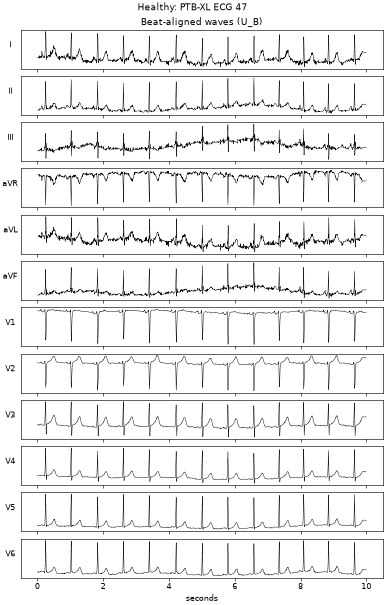

ECG 47 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


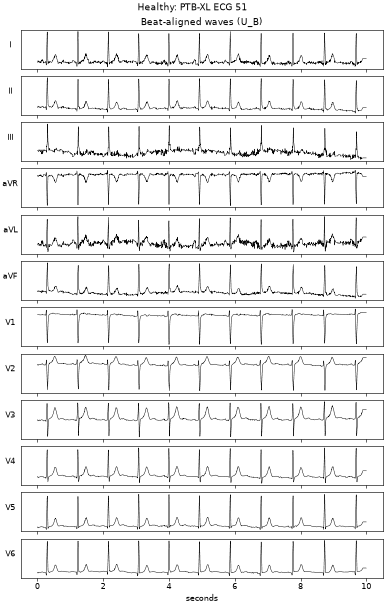

ECG 51 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


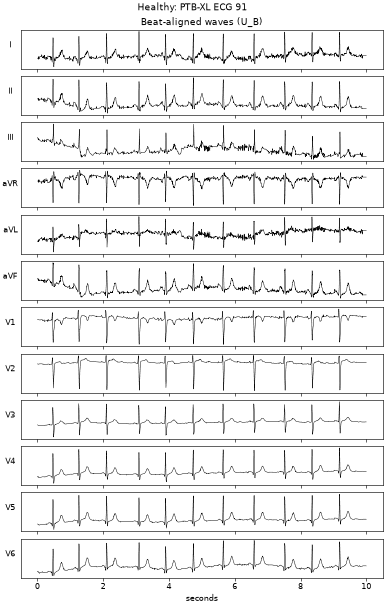

ECG 91 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


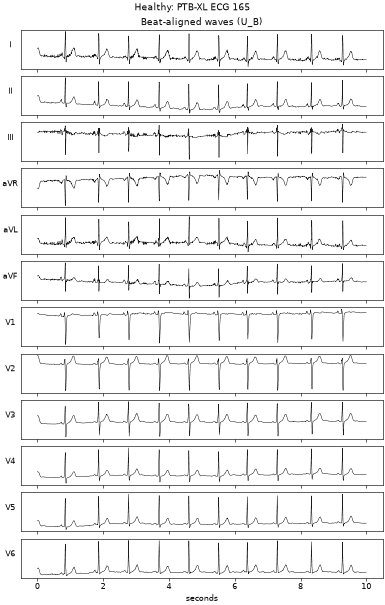

ECG 165 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [9]:
show_group("Healthy", 4)

No red wave on any of the four healthy ECGs, and no red band in notebook 11 either.

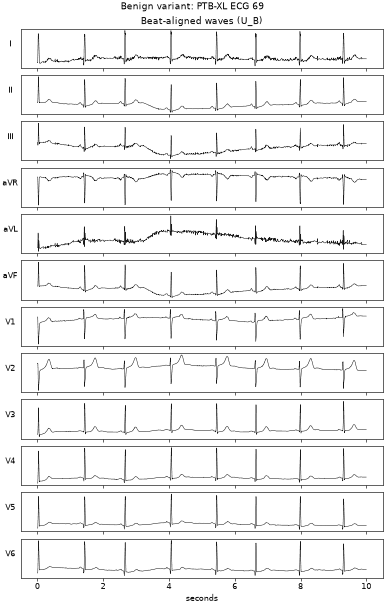

ECG 69 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): [np.float64(0.75), np.float64(2.0)] | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


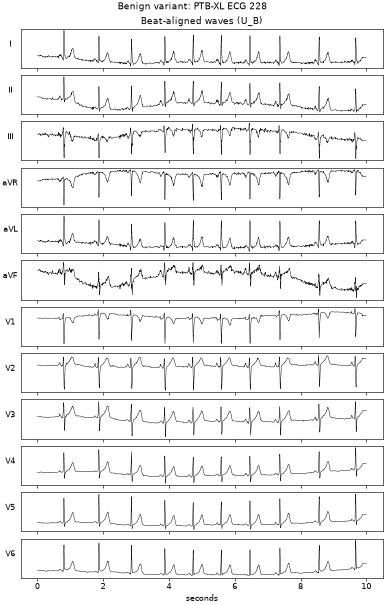

ECG 228 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [10]:
show_group("Benign variant", 2)

No red wave on either benign variant. Notebook 11 painted two bands on ECG 69 (at 0.75 s and 2.0 s, in the long pauses between beats); comparing the shape of each wave instead of time windows removes them. Over all 52 benign-variant ECGs, 8% get some red, against 27% in notebook 11.

## 5. Different cardiopathies

Two ECGs per group, the lowest-numbered in the development set, as in notebook 11.

**Premature ventricular beat (PVC).** An early, wide beat that starts in the ventricles.

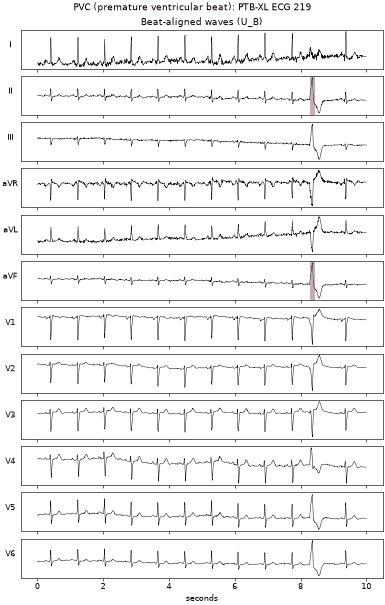

ECG 219 | red waves (lead, wave, beat R time): ['II QRS at 8.36 s', 'aVF QRS at 8.36 s']
           | 041 red bands start at (s): [np.float64(8.25), np.float64(8.5), np.float64(8.75)] | early beats by the rule at (s): [8.36] | max difference from saved scores: 0.0e+00


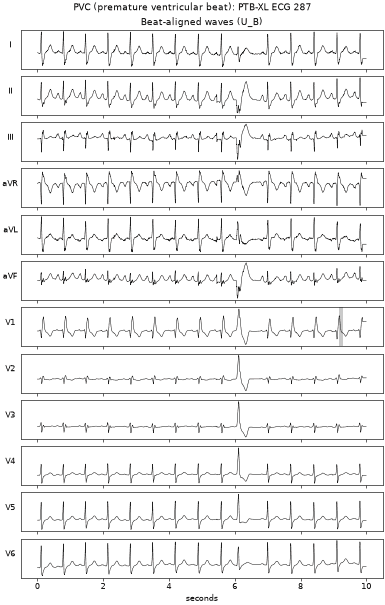

ECG 287 | red waves (lead, wave, beat R time): ['V1 ST at 9.10 s']
           | 041 red bands start at (s): [np.float64(6.0), np.float64(6.25), np.float64(6.5)] | early beats by the rule at (s): [6.11] | max difference from saved scores: 0.0e+00


In [11]:
show_group("PVC (premature ventricular beat)", 2)

ECG 219 is the one shown above. ECG 287, which also has a complete left bundle branch block, gets one red wave, the ST of the beat at 9.10 s in V1, and misses the early beat at 6.11 s that notebook 11 marked. Over all PVC ECGs, the reddest unit was on the premature beat 93% of the time (section 6), but only 77% of PVC ECGs get a red wave at all.

**Anterior myocardial infarction.** Damage to the front wall, expected in V1-V4.

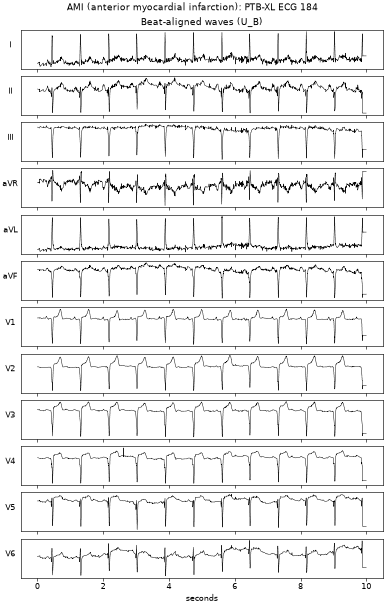

ECG 184 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


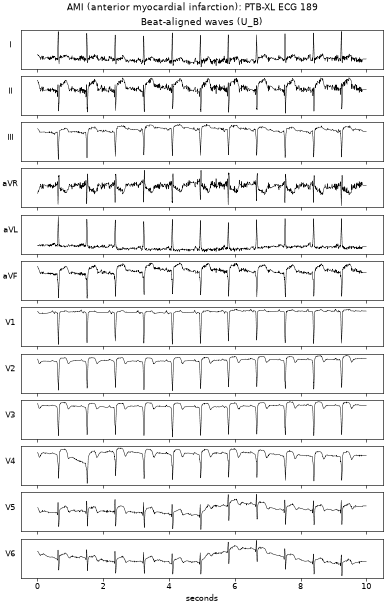

ECG 189 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [12]:
show_group("AMI (anterior myocardial infarction)", 2)

No red wave in either ECG, as in notebook 11. An infarct changes the QRS and ST of every beat a little, often not enough to cross the threshold: 34% of the 229 anterior infarcts get some red.

**Inferior myocardial infarction.** Damage to the lower wall, expected in II, III and aVF.

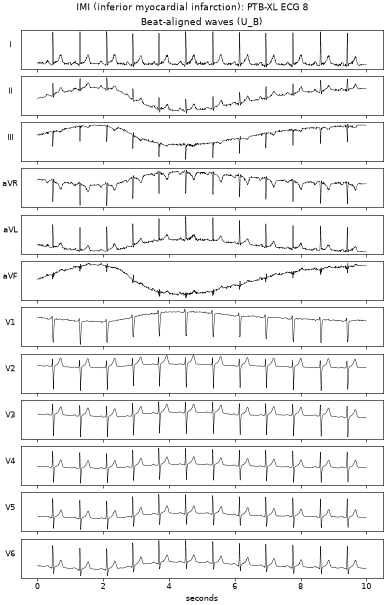

ECG 8 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


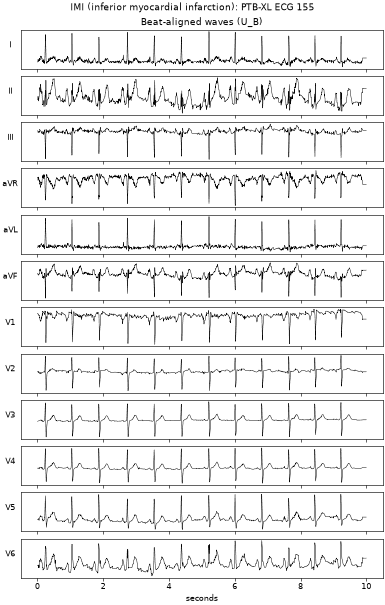

ECG 155 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [13]:
show_group("IMI (inferior myocardial infarction)", 2)

No red wave in either. 26% of the 227 inferior infarcts get some red, about the same as in notebook 11 (28%).

**Anterior ischemia.** ST depression or T-wave inversion in the front leads.

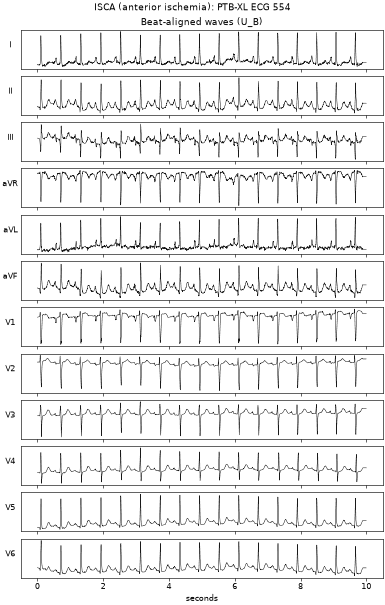

ECG 554 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


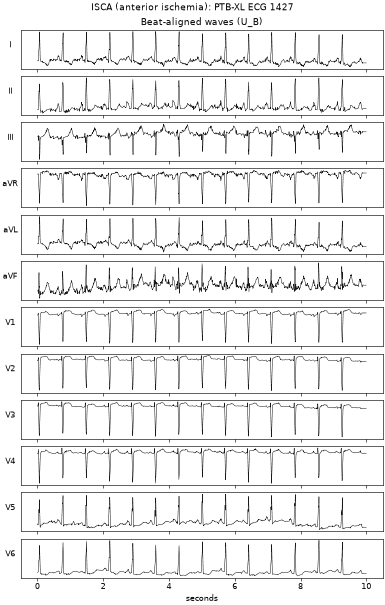

ECG 1427 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [14]:
show_group("ISCA (anterior ischemia)", 2)

No red wave in either. 27% of the 66 anterior ischemia ECGs get some red, the same as in notebook 11.

**Non-specific ST/T change.** Repolarization changes without a specific cause.

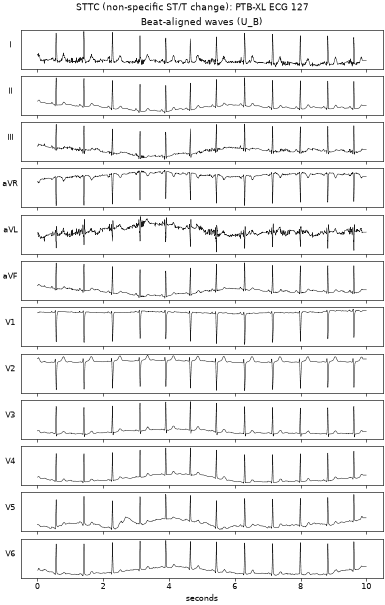

ECG 127 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


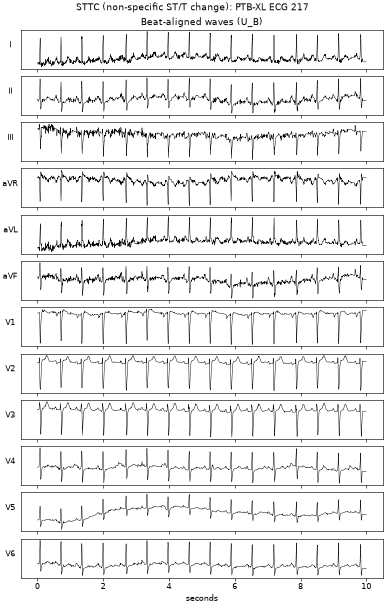

ECG 217 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [15]:
show_group("STTC (non-specific ST/T change)", 2)

No red wave in either. Subtle ST/T changes are the hardest group: 22% get some red.

**Left ventricular hypertrophy.** Tall QRS voltages, often with ST-T strain.

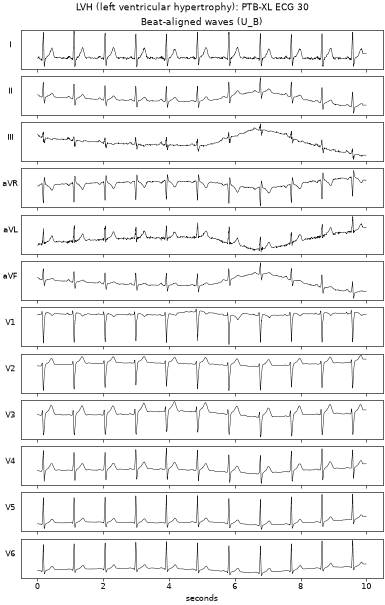

ECG 30 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


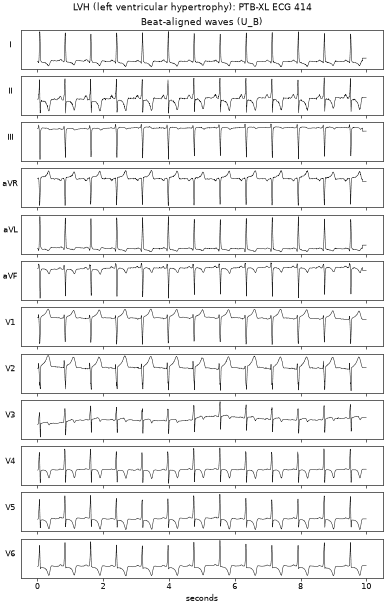

ECG 414 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [16]:
show_group("LVH (left ventricular hypertrophy)", 2)

No red wave in either. 31% of the 136 hypertrophy ECGs get some red (notebook 11: 25%).

**Complete left bundle branch block.** Every QRS is wide.

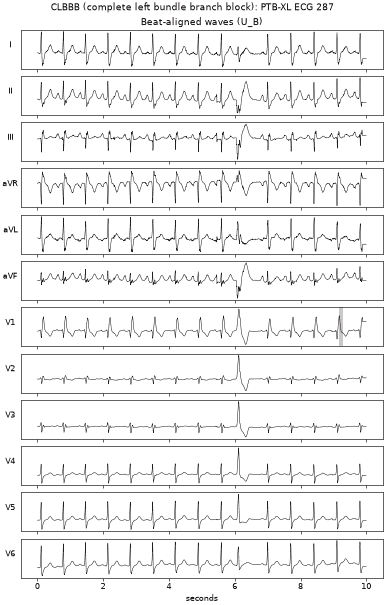

ECG 287 | red waves (lead, wave, beat R time): ['V1 ST at 9.10 s']
           | 041 red bands start at (s): [np.float64(6.0), np.float64(6.25), np.float64(6.5)] | early beats by the rule at (s): [6.11] | max difference from saved scores: 0.0e+00


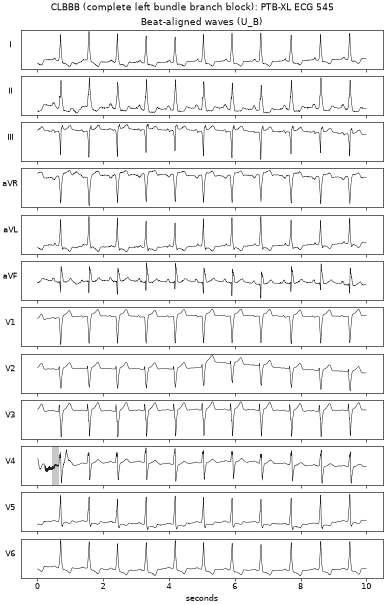

ECG 545 | red waves (lead, wave, beat R time): ['V4 P at 0.70 s']
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [17]:
show_group("CLBBB (complete left bundle branch block)", 2)

ECG 287 is the one shown above (one red wave, V1 ST at 9.10 s). ECG 545 gets one red wave, the P window of the beat at 0.70 s in V4. Over all 40 complete left bundle branch blocks, 78% get some red, with 61.5 red waves on average, against 22% with any red in notebook 11.

**Complete right bundle branch block.** Wide QRS with an rSR' pattern in V1.

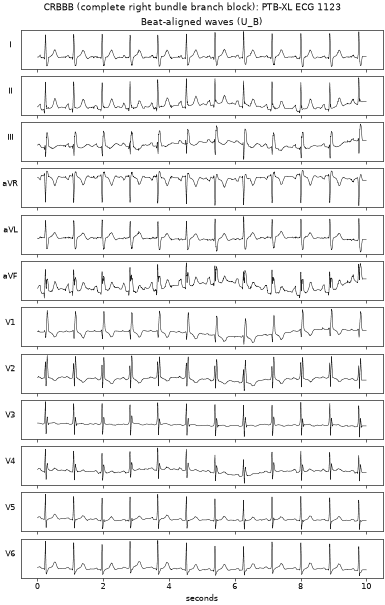

ECG 1123 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


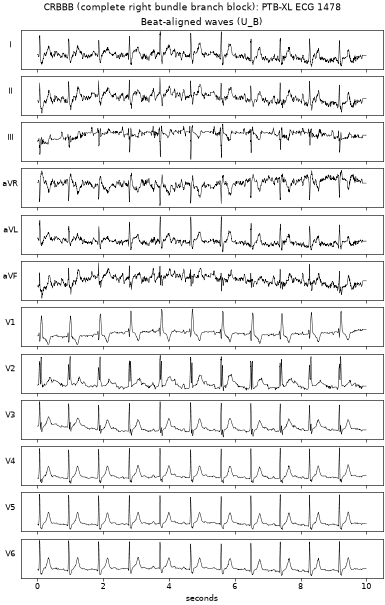

ECG 1478 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [18]:
show_group("CRBBB (complete right bundle branch block)", 2)

No red wave in either example, although 41% of the 37 complete right bundle branch blocks get some red (notebook 11: 14%).

**Incomplete right bundle branch block.** A milder version, common in athletes.

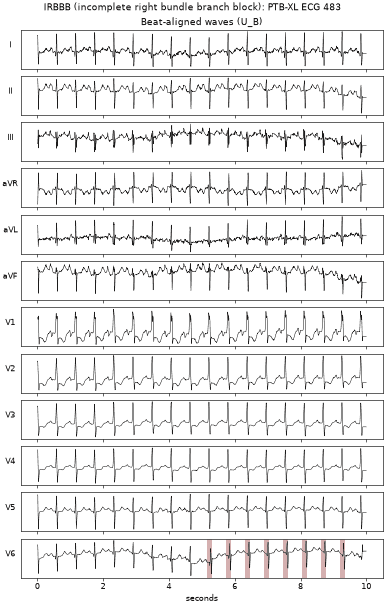

ECG 483 | red waves (lead, wave, beat R time): ['V6 QRS at 5.21 s', 'V6 QRS at 5.79 s', 'V6 QRS at 6.38 s', 'V6 QRS at 6.96 s', 'V6 QRS at 7.54 s', 'V6 QRS at 8.11 s', 'V6 QRS at 8.69 s', 'V6 QRS at 9.26 s']
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


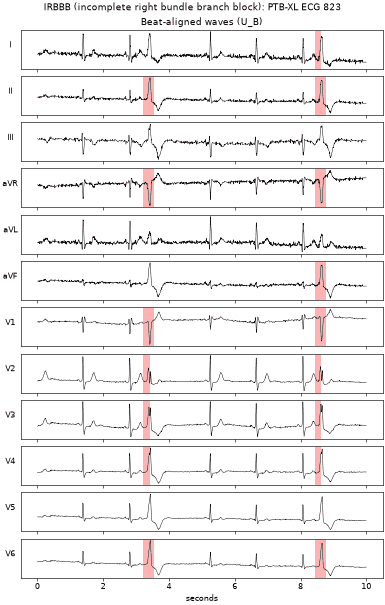

ECG 823 | red waves (lead, wave, beat R time): ['II P at 3.47 s', 'II QRS at 3.47 s', 'aVR P at 3.47 s', 'aVR QRS at 3.47 s', 'V1 P at 3.47 s', 'V1 QRS at 3.47 s', 'V2 P at 3.47 s', 'V3 P at 3.47 s', 'V4 P at 3.47 s', 'V6 P at 3.47 s', 'V6 QRS at 3.47 s', 'I P at 8.69 s', 'II P at 8.69 s', 'II QRS at 8.69 s', 'aVR P at 8.69 s', 'aVR QRS at 8.69 s', 'aVF P at 8.69 s', 'aVF QRS at 8.69 s', 'V1 P at 8.69 s', 'V1 QRS at 8.69 s', 'V2 P at 8.69 s', 'V3 P at 8.69 s', 'V4 P at 8.69 s', 'V6 P at 8.69 s', 'V6 QRS at 8.69 s']
           | 041 red bands start at (s): [np.float64(3.5), np.float64(3.75), np.float64(4.0), np.float64(4.25), np.float64(8.5), np.float64(8.75), np.float64(9.0)] | early beats by the rule at (s): [3.47, 8.69] | max difference from saved scores: 0.0e+00


In [19]:
show_group("IRBBB (incomplete right bundle branch block)", 2)

ECG 483: the QRS in V6 is red in the 8 beats from 5.21 s to 9.26 s, the same lead and wave beat after beat. ECG 823 has two early beats (the rule finds them at 3.47 s and 8.69 s), and only those two beats are red, in the P and QRS windows of several leads. Notebook 11 marked the same two beats as time bands, without leads.

**Fascicular block.** The QRS axis of every beat is shifted.

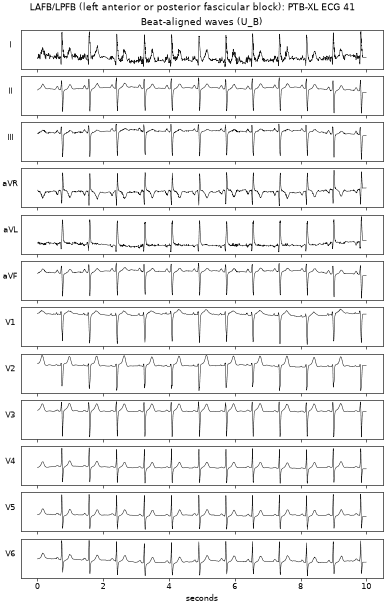

ECG 41 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


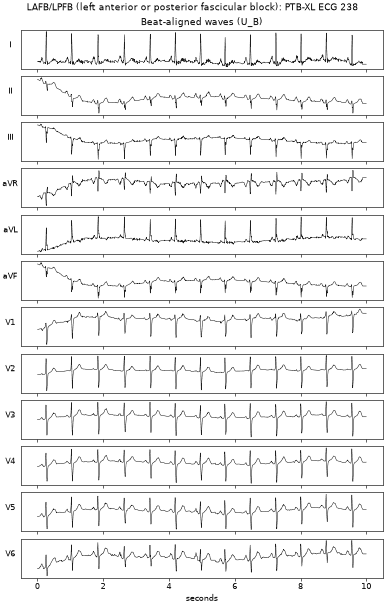

ECG 238 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [20]:
show_group("LAFB/LPFB (left anterior or posterior fascicular block)", 2)

No red wave in either. 32% of the 144 fascicular blocks get some red.

**Atrioventricular block.** A long PR interval or dropped beats.

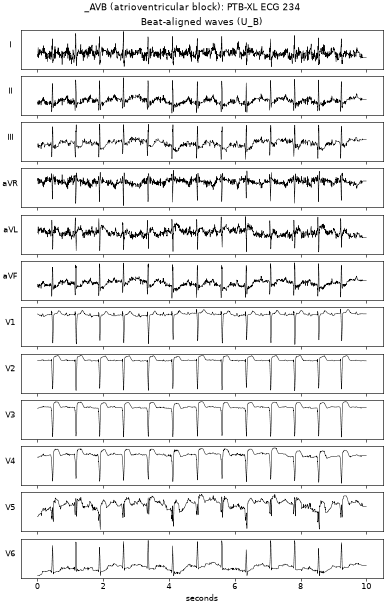

ECG 234 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): [np.float64(0.75), np.float64(1.5), np.float64(2.25), np.float64(3.0), np.float64(3.75), np.float64(4.5)] | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


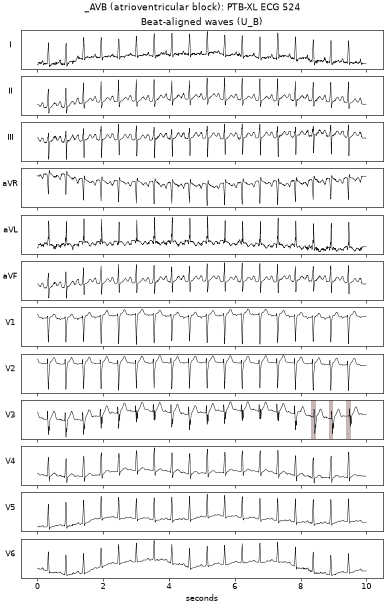

ECG 524 | red waves (lead, wave, beat R time): ['V3 QRS at 8.38 s', 'V3 QRS at 8.92 s', 'V3 QRS at 9.46 s']
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


In [21]:
show_group("_AVB (atrioventricular block)", 2)

ECG 234 gets no red wave (notebook 11 painted six thin bands in its noisy first half). ECG 524 gets three: the QRS in V3 of its last three beats (8.38-9.46 s).

**Wolff-Parkinson-White.** Short PR and a slurred QRS start in every beat.

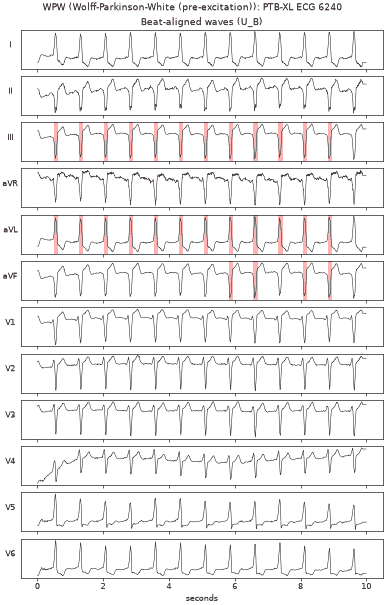

ECG 6240 | red waves (lead, wave, beat R time): ['III QRS at 0.56 s', 'aVL QRS at 0.56 s', 'III QRS at 1.32 s', 'aVL QRS at 1.32 s', 'III QRS at 2.08 s', 'aVL QRS at 2.08 s', 'III QRS at 2.84 s', 'aVL QRS at 2.84 s', 'III QRS at 3.60 s', 'aVL QRS at 3.60 s', 'III QRS at 4.36 s', 'aVL QRS at 4.36 s', 'III QRS at 5.11 s', 'aVL QRS at 5.11 s', 'III QRS at 5.87 s', 'aVL QRS at 5.87 s', 'aVF QRS at 5.87 s', 'III QRS at 6.62 s', 'aVL QRS at 6.62 s', 'aVF QRS at 6.62 s', 'III QRS at 7.38 s', 'aVL QRS at 7.38 s', 'III QRS at 8.13 s', 'aVL QRS at 8.13 s', 'aVF QRS at 8.13 s', 'III QRS at 8.88 s', 'aVL QRS at 8.88 s', 'aVF QRS at 8.88 s']
           | 041 red bands start at (s): none | early beats by the rule at (s): [] | max difference from saved scores: 0.0e+00


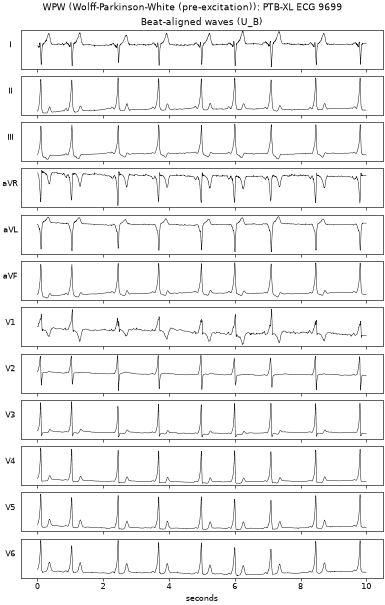

ECG 9699 | red waves (lead, wave, beat R time): none
           | 041 red bands start at (s): [np.float64(3.5), np.float64(8.25)] | early beats by the rule at (s): [1.04] | max difference from saved scores: 0.0e+00


In [22]:
show_group("WPW (Wolff-Parkinson-White (pre-excitation))", 2)

ECG 6240 is the clearest example of a finding in every beat: the QRS is red in III and aVL in every beat from 0.56 s to 8.88 s, and in aVF in four of them. The map shows the same wave, in the same leads, beat after beat. ECG 9699 gets nothing. Only 6 WPW ECGs are in the development set.

## 6. The experiment's numbers

From the saved Experiment 042 result. "Hit" means the reddest unit is on a rule-detected premature beat;
"lead contrast" asks whether anterior infarcts put their reddest unit in V1-V4 more often than inferior
infarcts do.

In [23]:
rows = {}
for name, label in (("U_B", "beat-aligned waves (this notebook)"), ("U_J", "ECG-JEPA patches")):
    found = result["maps"][name]
    rows[label] = {"premature beat: hit": found["hit_rate"], "chance": found["chance_rate"],
                   "benign: any red": found["any_red"]["benign"],
                   "healthy: any red": found["any_red"]["normal"],
                   "AUROC (reddest unit)": found["auroc"],
                   "lead contrast": found["lead_contrast"]["anterior"]["value"],
                   "lead contrast, 95% low": found["lead_contrast"]["anterior"]["ci_low"]}
old = result041["maps"]["U"]
rows["time bands (notebook 11)"] = {"premature beat: hit": old["hit_rate"], "chance": old["chance_rate"],
                                    "benign: any red": old["any_red"]["benign"],
                                    "healthy: any red": old["any_red"]["normal"],
                                    "AUROC (reddest unit)": old["auroc"]}
display(pd.DataFrame(rows).T.round(3))
print("Prespecified readings:", result["reading"])

,premature beat: hit,chance,benign: any red,healthy: any red,AUROC (reddest unit),lead contrast,"lead contrast, 95% low"
beat-aligned waves (this notebook),0.932,0.197,0.077,0.052,0.740,0.085,-0.038
ECG-JEPA patches,0.411,0.147,0.135,0.052,0.745,0.063,-0.051
time bands (notebook 11),0.822,0.153,0.269,0.052,0.777,NaN,NaN


Prespecified readings: {'J': {'keeps_premature_localization': False, 'gains': {'lead': False, 'detection': False, 'benign': False}, 'improves_on_041': False}, 'B': {'keeps_premature_localization': True, 'gains': {'lead': False, 'detection': False, 'benign': True}, 'improves_on_041': True}, 'notebook': True}


## 7. So, did it improve?

Yes, for two of the three things we wanted, by the experiment's own prespecified rule.

- **Finding the odd beat: better.** The reddest unit was on the premature beat in 93% of PVC ECGs (chance 20%),
  against 82% for notebook 11, and the map now names the leads and the wave.
- **Leaving benign variants alone: better.** 8% of benign-variant ECGs get red, against 27%. Comparing the
  shape of each wave ignores the slower or irregular spacing of the beats.
- **Some findings in every beat now show as a pattern:** the same wave in the same leads, beat after beat
  (WPW ECG 6240, incomplete right bundle branch block ECG 483).

What did not improve:

- **Screening.** The reddest unit alone detects abnormal ECGs with AUROC 0.740, a little below notebook 11
  (0.777). The whole-ECG readout should still decide who is referred; this map is for explaining.
- **Infarcts.** Most infarct, ischemia and ST/T examples get no red, and the infarct lead test did not pass:
  anterior infarcts put their reddest unit in V1-V4 only 8.5 points more often than inferior ones, with an
  interval that crosses zero.
- **Fixed wave windows.** In a wide-QRS beat, the QRS spills into the ST window (the red V1 ST of ECG 287).

The ECG-JEPA version was tested in the same experiment and did not improve on notebook 11, so it is not shown.
Next in the backlog: wave windows that follow each ECG's QRS width and QT interval, and a page where the
cardiologist marks abnormal leads and waves, so location can be checked properly.